# Analisis dan Visualisasi Data Penjualan

## 1. Import Library

Memuat semua library Python yang dibutuhkan untuk analisis data, visualisasi, dan pemodelan.

In [10]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Mengatur style plot untuk konsistensi visualisasi
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Load Dataset

Memuat dataset penjualan dari file CSV ke dalam Pandas DataFrame dan menampilkan beberapa baris pertama untuk pratinjau.

In [11]:
# Tentukan path ke file CSV
csv_path = '/content/data_praktikum_analisis_data.csv'

# Memuat dataset
try:
    df = pd.read_csv(csv_path)
    print("Dataset berhasil dimuat.")
    # Menampilkan 5 baris pertama dari DataFrame
    print("\nMenampilkan 5 baris pertama:")
    display(df.head())
except FileNotFoundError:
    print(f"Error: File '{csv_path}' tidak ditemukan. Pastikan file sudah diunggah dengan benar.")
except Exception as e:
    print(f"Terjadi kesalahan saat memuat CSV: {e}")

Dataset berhasil dimuat.

Menampilkan 5 baris pertama:


,Order_ID,CustomerID,Order_Date,Product_Category,Quantity,Price_Per_Unit,Ad_Budget,Total_Sales
0,1001,5039,2023-08-19,Books,4,1184000.0,982000.0,4736000.0
1,1002,5029,2023-08-29,Fashion,5,1733000.0,3513000.0,8665000.0
2,1003,5015,2023-02-21,Fashion,4,1767000.0,2117000.0,7068000.0
3,1004,5043,2023-04-06,Fashion,2,512000.0,4384000.0,1024000.0
4,1005,5008,2023-08-10,Home Decor,2,1820000.0,2625000.0,3640000.0


## 3. Inspeksi Data Awal

Melakukan inspeksi awal pada data untuk memahami struktur, tipe data, dan keberadaan nilai yang hilang.

In [12]:
# Menampilkan informasi umum tentang DataFrame, termasuk tipe data dan jumlah non-null
print("\nInformasi DataFrame (df.info()):")
df.info()


Informasi DataFrame (df.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          150 non-null    int64  
 1   CustomerID        150 non-null    int64  
 2   Order_Date        150 non-null    object 
 3   Product_Category  150 non-null    object 
 4   Quantity          150 non-null    int64  
 5   Price_Per_Unit    150 non-null    float64
 6   Ad_Budget         150 non-null    float64
 7   Total_Sales       143 non-null    float64
dtypes: float64(3), int64(3), object(2)
memory usage: 9.5+ KB


In [13]:
# Menghitung jumlah nilai yang hilang di setiap kolom
print("\nJumlah nilai null di setiap kolom (df.isnull().sum()):")
display(df.isnull().sum())


Jumlah nilai null di setiap kolom (df.isnull().sum()):


,0
Order_ID,0
CustomerID,0
Order_Date,0
Product_Category,0
Quantity,0
Price_Per_Unit,0
Ad_Budget,0
Total_Sales,7


## 4. Data Cleaning

Menangani nilai yang hilang di kolom 'Total_Sales' dengan imputasi median untuk menjaga kualitas data dan menghindari `FutureWarning`.

In [14]:
# Mengidentifikasi nilai yang hilang di 'Total_Sales' sebelum imputasi
missing_total_sales_before = df['Total_Sales'].isnull().sum()
print(f"Jumlah nilai yang hilang di 'Total_Sales' sebelum imputasi: {missing_total_sales_before}")

# Menghitung median dari kolom 'Total_Sales'
median_total_sales = df['Total_Sales'].median()

# Mengimputasi nilai yang hilang dengan median
df['Total_Sales'] = df['Total_Sales'].fillna(median_total_sales)

# Memverifikasi bahwa nilai yang hilang telah ditangani
missing_total_sales_after = df['Total_Sales'].isnull().sum()
print(f"Jumlah nilai yang hilang di 'Total_Sales' setelah imputasi: {missing_total_sales_after}")

# Menampilkan statistik deskriptif lagi untuk mencerminkan perubahan di 'Total_Sales'
print("\nStatistik deskriptif setelah imputasi:")
display(df.describe())

Jumlah nilai yang hilang di 'Total_Sales' sebelum imputasi: 7
Jumlah nilai yang hilang di 'Total_Sales' setelah imputasi: 0

Statistik deskriptif setelah imputasi:


,Order_ID,CustomerID,Quantity,Price_Per_Unit,Ad_Budget,Total_Sales
count,150.000000,150.000000,150.000000,1.500000e+02,1.500000e+02,1.500000e+02
mean,1075.500000,5024.333333,3.066667,1.024640e+06,2.618947e+06,3.163747e+06
std,43.445368,14.094916,1.450141,5.404436e+05,1.415329e+06,2.454300e+06
min,1001.000000,5001.000000,1.000000,7.700000e+04,1.130000e+05,7.700000e+04
25%,1038.250000,5012.250000,2.000000,5.750000e+05,1.385000e+06,1.422000e+06
50%,1075.500000,5024.000000,3.000000,9.880000e+05,2.722500e+06,2.355000e+06
75%,1112.750000,5036.750000,4.000000,1.493000e+06,3.768500e+06,4.270500e+06
max,1150.000000,5049.000000,5.000000,1.992000e+06,4.987000e+06,9.810000e+06


## 5. Konversi Kolom Tanggal

Mengkonversi kolom 'Order_Date' ke tipe data datetime untuk analisis berbasis waktu, dan mengekstrak informasi bulan.

In [15]:
# Mengkonversi kolom 'Order_Date' ke tipe datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Mengekstrak bulan dari 'Order_Date' untuk analisis bulanan
df['Order_Month'] = df['Order_Date'].dt.to_period('M')

print("Kolom 'Order_Date' telah dikonversi ke tipe datetime dan 'Order_Month' telah dibuat.")
display(df.head())

Kolom 'Order_Date' telah dikonversi ke tipe datetime dan 'Order_Month' telah dibuat.


,Order_ID,CustomerID,Order_Date,Product_Category,Quantity,Price_Per_Unit,Ad_Budget,Total_Sales,Order_Month
0,1001,5039,2023-08-19,Books,4,1184000.0,982000.0,4736000.0,2023-08
1,1002,5029,2023-08-29,Fashion,5,1733000.0,3513000.0,8665000.0,2023-08
2,1003,5015,2023-02-21,Fashion,4,1767000.0,2117000.0,7068000.0,2023-02
3,1004,5043,2023-04-06,Fashion,2,512000.0,4384000.0,1024000.0,2023-04
4,1005,5008,2023-08-10,Home Decor,2,1820000.0,2625000.0,3640000.0,2023-08


## 6. Analisis Tren Penjualan Bulanan

Menganalisis bagaimana total penjualan berubah dari bulan ke bulan.

In [16]:
# Menghitung total penjualan bulanan
monthly_sales = df.groupby('Order_Month')['Total_Sales'].sum().reset_index()
monthly_sales['Order_Month'] = monthly_sales['Order_Month'].astype(str) # Convert to string for plotting

print("Total penjualan bulanan:")
display(monthly_sales)

Total penjualan bulanan:


,Order_Month,Total_Sales
0,2023-01,19910000.0
1,2023-02,39524000.0
2,2023-03,24003000.0
3,2023-04,52149000.0
4,2023-05,55082000.0
5,2023-06,44580000.0
6,2023-07,24264000.0
7,2023-08,83500000.0
8,2023-09,42062000.0
9,2023-10,23454000.0


## 7. Visualisasi Line Chart Tren Penjualan Bulanan

Memvisualisasikan tren penjualan bulanan menggunakan line chart untuk melihat pola atau musiman.

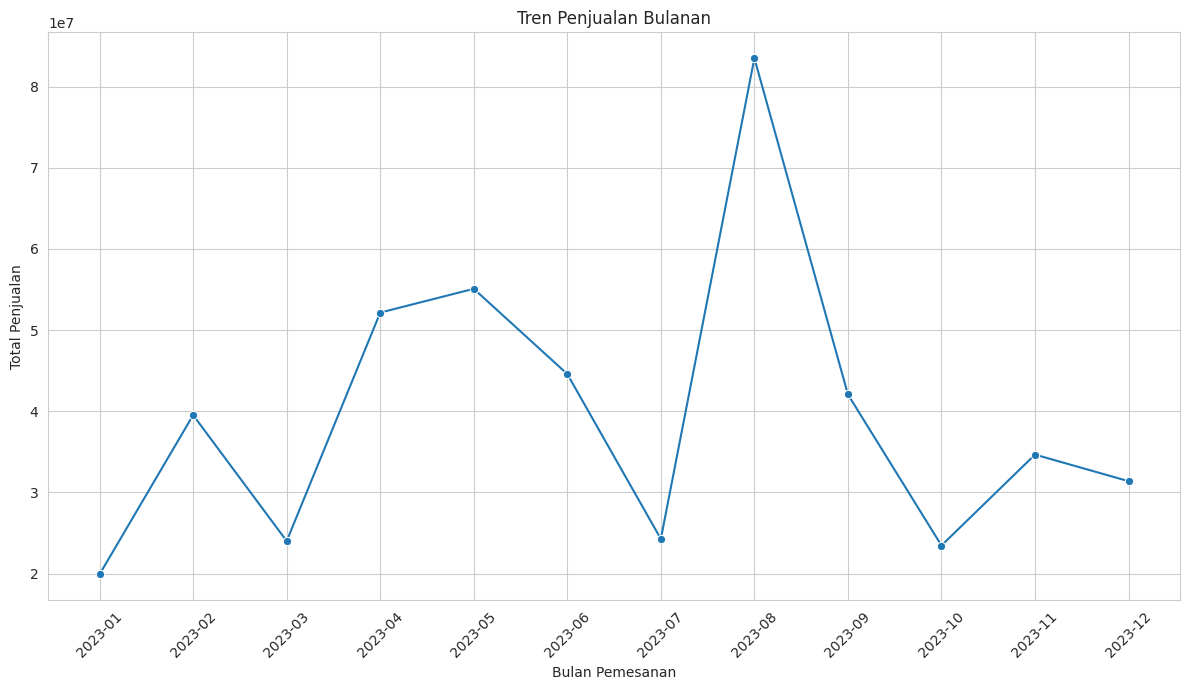

In [17]:
# Membuat line chart untuk tren penjualan bulanan
plt.figure(figsize=(12, 7))
sns.lineplot(x='Order_Month', y='Total_Sales', data=monthly_sales, marker='o')
plt.title('Tren Penjualan Bulanan')
plt.xlabel('Bulan Pemesanan')
plt.ylabel('Total Penjualan')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Analisis Korelasi

Menganalisis hubungan antara 'Ad_Budget' dan 'Total_Sales', serta korelasi antar variabel numerik lainnya.

In [18]:
# Menghitung koefisien korelasi antara 'Ad_Budget' dan 'Total_Sales'
correlation_ad_sales = df['Ad_Budget'].corr(df['Total_Sales'])
print(f"Koefisien korelasi antara Ad_Budget dan Total_Sales adalah: {correlation_ad_sales:.4f}")

Koefisien korelasi antara Ad_Budget dan Total_Sales adalah: 0.0453


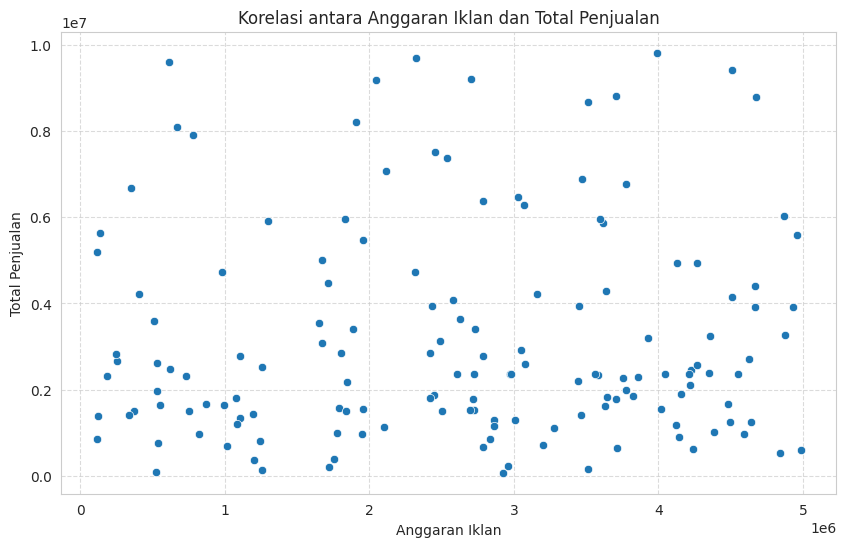

In [19]:
# Membuat scatter plot untuk memvisualisasikan korelasi antara 'Ad_Budget' dan 'Total_Sales'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Ad_Budget', y='Total_Sales', data=df)
plt.title('Korelasi antara Anggaran Iklan dan Total Penjualan')
plt.xlabel('Anggaran Iklan')
plt.ylabel('Total Penjualan')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 9. Visualisasi Heatmap Korelasi

Memvisualisasikan matriks korelasi dari semua variabel numerik menggunakan heatmap untuk melihat hubungan secara keseluruhan.

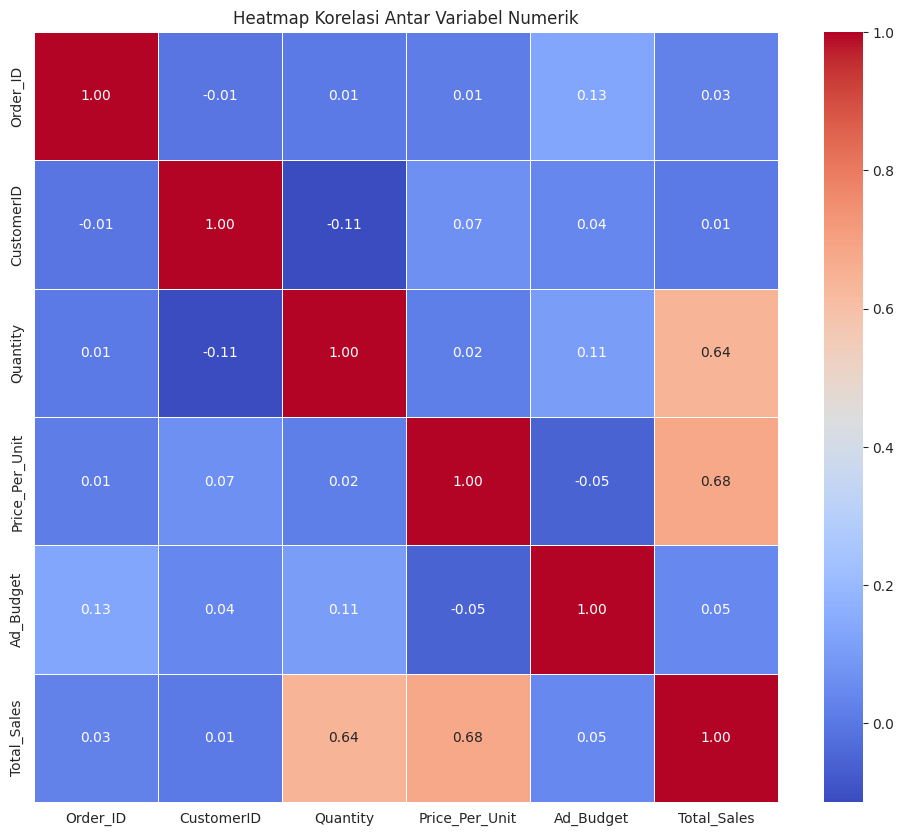

In [20]:
# Memilih kolom numerik untuk analisis korelasi
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
correlation_matrix = df[numeric_cols].corr()

# Membuat heatmap korelasi
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap Korelasi Antar Variabel Numerik')
plt.show()

## 10. Identifikasi Produk Underperformer

Menganalisis kategori produk untuk mengidentifikasi mana yang memiliki performa penjualan terendah.

In [21]:
# Menghitung total penjualan per kategori produk
category_sales = df.groupby('Product_Category')['Total_Sales'].sum().sort_values(ascending=True).reset_index()

print("Total penjualan per kategori produk (dari terendah ke tertinggi):")
display(category_sales)

# Mengidentifikasi kategori dengan penjualan terendah (underperformer)
underperformer_category = category_sales.iloc[0]
print(f"\nKategori produk dengan penjualan terendah (Underperformer): {underperformer_category['Product_Category']} dengan total penjualan {underperformer_category['Total_Sales']:.2f}")

Total penjualan per kategori produk (dari terendah ke tertinggi):


,Product_Category,Total_Sales
0,Home Decor,74050000.0
1,Gadget,75233000.0
2,Fashion,98905000.0
3,Books,112279000.0
4,Electronics,114095000.0



Kategori produk dengan penjualan terendah (Underperformer): Home Decor dengan total penjualan 74050000.00


## 11. Visualisasi Bar Chart (Produk Underperformer)

Memvisualisasikan penjualan per kategori produk untuk menyoroti underperformer.

/tmp/ipykernel_2977/1421185477.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total_Sales', y='Product_Category', data=category_sales, palette='viridis')


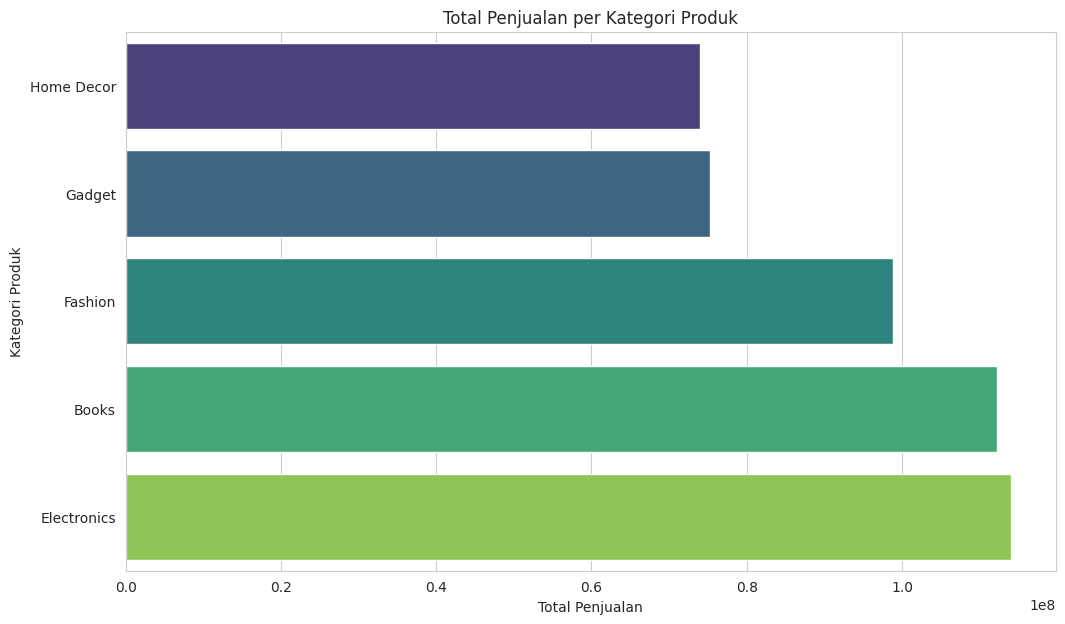

In [22]:
# Membuat bar chart untuk total penjualan per kategori produk
plt.figure(figsize=(12, 7))
sns.barplot(x='Total_Sales', y='Product_Category', data=category_sales, palette='viridis')
plt.title('Total Penjualan per Kategori Produk')
plt.xlabel('Total Penjualan')
plt.ylabel('Kategori Produk')
plt.show()

## 12. RFM Analysis (Recency, Frequency, Monetary)

Menganalisis nilai pelanggan berdasarkan Recency (kapan terakhir kali membeli), Frequency (seberapa sering membeli), dan Monetary (berapa banyak yang dihabiskan).

In [23]:
# Tentukan tanggal referensi (misalnya, satu hari setelah tanggal pesanan terakhir di dataset)
snapshot_date = df['Order_Date'].max() + pd.Timedelta(days=1)

# Hitung Recency, Frequency, Monetary
rfm = df.groupby('CustomerID').agg(
    Recency=('Order_Date', lambda date: (snapshot_date - date.max()).days),
    Frequency=('Order_ID', 'nunique'),
    Monetary=('Total_Sales', 'sum')
).reset_index()

print("Hasil RFM Analysis:")
display(rfm.head())

Hasil RFM Analysis:


,CustomerID,Recency,Frequency,Monetary
0,5001,213,4,8562000.0
1,5002,77,4,9286000.0
2,5003,118,3,9433000.0
3,5004,196,3,17723000.0
4,5005,23,2,9105000.0


## 13. Analisis Efisiensi Kategori Produk

Menganalisis efisiensi penjualan per kategori produk, misalnya berdasarkan rata-rata penjualan per unit atau per pesanan.

In [24]:
# Menghitung rata-rata penjualan per kuantitas untuk setiap kategori produk sebagai metrik efisiensi
category_efficiency = df.groupby('Product_Category').agg(
    Avg_Sales_Per_Unit=('Total_Sales', lambda x: x.sum() / df.loc[x.index, 'Quantity'].sum())
).reset_index()

category_efficiency = category_efficiency.sort_values(by='Avg_Sales_Per_Unit', ascending=False)

print("Efisiensi Kategori Produk (Rata-rata Penjualan per Unit):")
display(category_efficiency)

Efisiensi Kategori Produk (Rata-rata Penjualan per Unit):


,Product_Category,Avg_Sales_Per_Unit
1,Electronics,1.140950e+06
4,Home Decor,1.042958e+06
2,Fashion,1.041105e+06
0,Books,1.020718e+06
3,Gadget,8.956310e+05


## 14. Visualisasi Bar Chart Horizontal Efisiensi Kategori Produk

Memvisualisasikan efisiensi kategori produk menggunakan bar chart horizontal.

/tmp/ipykernel_2977/598619315.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Avg_Sales_Per_Unit', y='Product_Category', data=category_efficiency, palette='magma')


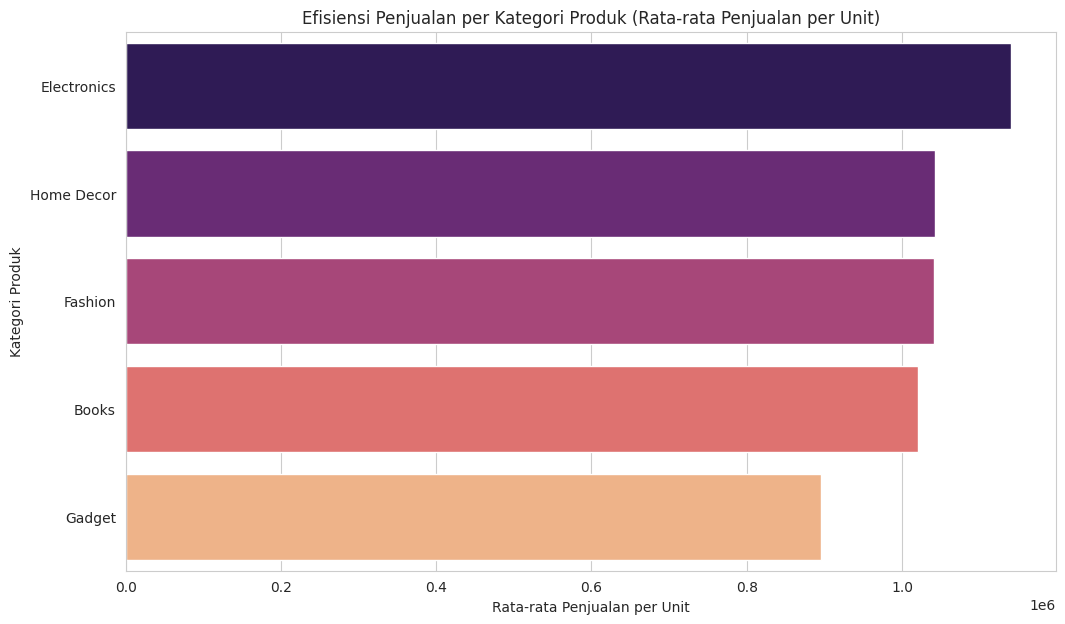

In [25]:
# Membuat bar chart horizontal untuk efisiensi kategori produk
plt.figure(figsize=(12, 7))
sns.barplot(x='Avg_Sales_Per_Unit', y='Product_Category', data=category_efficiency, palette='magma')
plt.title('Efisiensi Penjualan per Kategori Produk (Rata-rata Penjualan per Unit)')
plt.xlabel('Rata-rata Penjualan per Unit')
plt.ylabel('Kategori Produk')
plt.show()

## 15. Uji Hipotesis: Ad_Budget Tinggi vs Rendah

Melakukan uji statistik untuk menentukan apakah ada perbedaan signifikan dalam 'Total_Sales' antara kelompok 'Ad_Budget' tinggi dan rendah.

In [26]:
# Mendefinisikan kelompok 'Ad_Budget' tinggi dan rendah menggunakan median sebagai batas
median_ad_budget = df['Ad_Budget'].median()
df['Ad_Budget_Group'] = ['High' if x >= median_ad_budget else 'Low' for x in df['Ad_Budget']]

# Memisahkan Total_Sales untuk kedua kelompok
sales_high_ad = df[df['Ad_Budget_Group'] == 'High']['Total_Sales']
sales_low_ad = df[df['Ad_Budget_Group'] == 'Low']['Total_Sales']

# Melakukan uji t-independent
t_stat, p_value = stats.ttest_ind(sales_high_ad, sales_low_ad)

print(f"T-statistik: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretasi hasil
alpha = 0.05
if p_value < alpha:
    print(f"\nDengan p-value ({p_value:.4f}) < alpha ({alpha}), kita menolak hipotesis nol.")
    print("Ada perbedaan signifikan dalam Total_Sales antara kelompok Ad_Budget tinggi dan rendah.")
else:
    print(f"\nDengan p-value ({p_value:.4f}) >= alpha ({alpha}), kita gagal menolak hipotesis nol.")
    print("Tidak ada perbedaan signifikan yang terbukti dalam Total_Sales antara kelompok Ad_Budget tinggi dan rendah.")

T-statistik: -0.3561
P-value: 0.7223

Dengan p-value (0.7223) >= alpha (0.05), kita gagal menolak hipotesis nol.
Tidak ada perbedaan signifikan yang terbukti dalam Total_Sales antara kelompok Ad_Budget tinggi dan rendah.
